# bart-base

this notebook was executed using Google Colab, so the code is written for this platform

In [1]:
%pip install -q -U \
    transformers \
    datasets \
    evaluate \
    accelerate \
    sentencepiece \
    rouge_score \
    bert_score


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 13.3 MB/s eta 0:00:00


In [2]:
import json
import os
import re
import shutil
import time
from getpass import getpass
from pathlib import Path

import evaluate
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch

from IPython.display import display
from datasets import DatasetDict, load_dataset
from transformers import (
    AutoModelForSeq2SeqLM,
    AutoTokenizer,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    set_seed,
)

SEED = 42
set_seed(SEED)


In [3]:
PROJECT_DIR = Path("/content/chatbrief")
DATA_DIR = PROJECT_DIR / "data"
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
MODEL_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results"

for directory in [DATA_DIR, CHECKPOINT_DIR, MODEL_DIR, RESULTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("RESULTS_DIR:", RESULTS_DIR)


PROJECT_DIR: /content/chatbrief
RESULTS_DIR: /content/chatbrief/results


## Дані


In [4]:
from google.colab import files

uploaded = files.upload()


Saving test_clean.csv to test_clean.csv
Saving train_clean.csv to train_clean.csv
Saving validation_clean.csv to validation_clean.csv


In [5]:
expected_files = [
    "train_clean.csv",
    "validation_clean.csv",
    "test_clean.csv",
]

for filename in expected_files:
    source = Path("/content") / filename
    destination = DATA_DIR / filename

    if not source.exists() and not destination.exists():
        raise FileNotFoundError(
            f"Файл {filename} не знайдено. Завантаж його у попередній клітинці."
        )

    if source.exists():
        shutil.copy2(source, destination)

print("Файли:")
for path in DATA_DIR.glob("*.csv"):
    print("-", path.name)


Файли:
- train_clean.csv
- validation_clean.csv
- test_clean.csv


In [6]:
data_files = {
    "train": str(DATA_DIR / "train_clean.csv"),
    "validation": str(DATA_DIR / "validation_clean.csv"),
    "test": str(DATA_DIR / "test_clean.csv"),
}

dataset = load_dataset("csv", data_files=data_files)

DIALOGUE_COL = "dialogue"
SUMMARY_COL = "summary"

print(dataset)


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 12460
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 467
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 1479
    })
})


## Конфігурація


In [7]:
MODEL_NAME = "facebook/bart-base"

TRAIN_SIZE = None
VALIDATION_SIZE = None
TEST_SIZE = None

NUM_EPOCHS = 5
LEARNING_RATE = 3e-5

TRAIN_BATCH_SIZE = 4
EVAL_BATCH_SIZE = 4
GRADIENT_ACCUMULATION_STEPS = 2

MAX_INPUT_LENGTH = 512
MAX_TARGET_LENGTH = 64
PREFIX = ""

EXPERIMENT_NAME = "bart_base_full_with_test"
OUTPUT_DIR = CHECKPOINT_DIR / EXPERIMENT_NAME
FINAL_MODEL_DIR = MODEL_DIR / f"{EXPERIMENT_NAME}_best"

print("Model:", MODEL_NAME)
print("Experiment:", EXPERIMENT_NAME)
print("Epochs:", NUM_EPOCHS)


Model: facebook/bart-base
Experiment: bart_base_full_with_test
Epochs: 5


In [8]:
def select_subset(split_dataset, size, seed=SEED):
    if size is None or size >= len(split_dataset):
        return split_dataset

    return split_dataset.shuffle(seed=seed).select(range(size))


experiment_dataset = DatasetDict({
    "train": select_subset(dataset["train"], TRAIN_SIZE),
    "validation": select_subset(dataset["validation"], VALIDATION_SIZE),
    "test": select_subset(dataset["test"], TEST_SIZE),
})

print(experiment_dataset)


DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 12460
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 467
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 1479
    })
})


## Модель і токенайзер


In [9]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)

print("Device:", device)
print("Parameters:", f"{model.num_parameters():,}")


config.json:   0%|          | 0.00/1.72k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  558MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

Device: cuda
Parameters: 139,420,416


## Аналіз довжин


In [10]:
def calculate_token_lengths(texts, prefix=""):
    return [
        len(
            tokenizer(
                prefix + str(text),
                add_special_tokens=True,
                truncation=False,
            )["input_ids"]
        )
        for text in texts
    ]


length_statistics = []

for split_name, split_dataset in experiment_dataset.items():
    input_lengths = calculate_token_lengths(
        split_dataset[DIALOGUE_COL],
        prefix=PREFIX,
    )
    target_lengths = calculate_token_lengths(
        split_dataset[SUMMARY_COL]
    )

    input_truncated = (
        np.mean(np.array(input_lengths) > MAX_INPUT_LENGTH) * 100
    )
    target_truncated = (
        np.mean(np.array(target_lengths) > MAX_TARGET_LENGTH) * 100
    )

    length_statistics.append({
        "split": split_name,
        "input_median": float(np.median(input_lengths)),
        "input_p95": float(np.percentile(input_lengths, 95)),
        "input_max": int(np.max(input_lengths)),
        "input_truncated_percent": round(input_truncated, 2),
        "target_median": float(np.median(target_lengths)),
        "target_p95": float(np.percentile(target_lengths, 95)),
        "target_max": int(np.max(target_lengths)),
        "target_truncated_percent": round(target_truncated, 2),
    })

token_length_df = pd.DataFrame(length_statistics)
token_length_df


,split,input_median,input_p95,input_max,input_truncated_percent,target_median,target_p95,target_max,target_truncated_percent
0,train,193.0,390.0,1429,1.52,34.0,64.05,249,5.00
1,validation,192.0,375.7,726,0.86,32.0,61.70,100,3.21
2,test,199.0,400.0,1366,1.42,28.0,51.00,104,1.28


## Preprocessing і токенізація


In [11]:
def preprocess_function(examples):
    inputs = [
        PREFIX + dialogue
        for dialogue in examples[DIALOGUE_COL]
    ]

    model_inputs = tokenizer(
        inputs,
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
    )

    labels = tokenizer(
        text_target=examples[SUMMARY_COL],
        max_length=MAX_TARGET_LENGTH,
        truncation=True,
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs


In [12]:
tokenized_dataset = experiment_dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=experiment_dataset["train"].column_names,
    desc="Tokenizing dataset",
)

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
)

print(tokenized_dataset)


Tokenizing dataset:   0%|          | 0/12460 [00:00<?, ? examples/s]

Tokenizing dataset:   0%|          | 0/467 [00:00<?, ? examples/s]

Tokenizing dataset:   0%|          | 0/1479 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 12460
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 467
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 1479
    })
})


## ROUGE


In [13]:
rouge_metric = evaluate.load("rouge")


def prepare_for_rouge(text):
    sentences = re.split(
        r"(?<=[.!?])\s+",
        text.strip(),
    )

    return "\n".join(
        sentence
        for sentence in sentences
        if sentence
    )


def compute_metrics(eval_predictions):
    predictions, labels = eval_predictions

    if isinstance(predictions, tuple):
        predictions = predictions[0]

    predictions = np.asarray(predictions)
    labels = np.asarray(labels)

    if predictions.ndim == 3:
        predictions = np.argmax(
            predictions,
            axis=-1,
        )

    predictions = np.where(
        predictions < 0,
        tokenizer.pad_token_id,
        predictions,
    ).astype(np.int64)

    labels = np.where(
        labels < 0,
        tokenizer.pad_token_id,
        labels,
    ).astype(np.int64)

    decoded_predictions = tokenizer.batch_decode(
        predictions,
        skip_special_tokens=True,
    )

    decoded_labels = tokenizer.batch_decode(
        labels,
        skip_special_tokens=True,
    )

    decoded_predictions = [
        prepare_for_rouge(text)
        for text in decoded_predictions
    ]

    decoded_labels = [
        prepare_for_rouge(text)
        for text in decoded_labels
    ]

    result = rouge_metric.compute(
        predictions=decoded_predictions,
        references=decoded_labels,
        use_stemmer=True,
    )

    prediction_lengths = [
        np.count_nonzero(
            prediction != tokenizer.pad_token_id
        )
        for prediction in predictions
    ]

    result = {
        metric_name: round(
            metric_value * 100,
            4,
        )
        for metric_name, metric_value in result.items()
    }

    result["gen_len"] = round(
        float(np.mean(prediction_lengths)),
        2,
    )

    return result

## Trainer


In [14]:
training_args = Seq2SeqTrainingArguments(
    output_dir=str(OUTPUT_DIR),

    num_train_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=0.01,
    warmup_ratio=0.1,

    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=25,

    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LENGTH,
    generation_num_beams=4,

    load_best_model_at_end=True,
    metric_for_best_model="rougeL",
    greater_is_better=True,
    save_total_limit=2,

    fp16=torch.cuda.is_available(),
    report_to="none",

    seed=SEED,
    data_seed=SEED,
)


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [15]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,

    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],

    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)


## Baseline


In [16]:
baseline_metrics = trainer.evaluate(
    metric_key_prefix="baseline"
)

baseline_metrics


Training Loss,Validation Loss,Epoch,Rouge1,Rouge2,Rougel,Rougelsum,Gen Len
No log,3.973844,0,26.370700,7.075900,19.640500,23.358100,63.980000


{'baseline_loss': 3.973843574523926,
 'baseline_rouge1': 26.3707,
 'baseline_rouge2': 7.0759,
 'baseline_rougeL': 19.6405,
 'baseline_rougeLsum': 23.3581,
 'baseline_gen_len': 63.98}

## Fine-tuning


In [17]:
train_result = trainer.train()

train_result.metrics


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum,Gen Len
1,2.681490,1.213495,46.782400,21.577800,38.641200,42.392800,32.880000
2,2.415028,1.130395,46.804300,22.480500,39.550300,42.519800,30.910000
3,2.064075,1.130208,47.575700,23.065300,39.964800,43.146500,34.080000
4,1.916234,1.117047,48.614000,24.848400,41.262600,44.135100,32.810000
5,1.813297,1.124357,48.441800,24.118700,40.756400,43.837300,33.100000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


{'train_runtime': 1961.0045,
 'train_samples_per_second': 31.769,
 'train_steps_per_second': 3.972,
 'total_flos': 1.156575504494592e+16,
 'train_loss': 2.2735399608587574,
 'epoch': 5.0}

## Validation evaluation


In [18]:
final_metrics = trainer.evaluate(
    metric_key_prefix="final"
)

final_metrics


Training Loss,Validation Loss,Epoch,Rouge1,Rouge2,Rougel,Rougelsum,Gen Len
1.813297,1.117047,5,48.614000,24.848400,41.262600,44.135100,32.810000


{'final_loss': 1.1170469522476196,
 'final_rouge1': 48.614,
 'final_rouge2': 24.8484,
 'final_rougeL': 41.2626,
 'final_rougeLsum': 44.1351,
 'final_gen_len': 32.81}

## Baseline vs fine-tuned


In [19]:
metric_names = [
    "rouge1",
    "rouge2",
    "rougeL",
    "rougeLsum",
    "gen_len",
    "loss",
]

comparison_rows = []

for metric_name in metric_names:
    baseline_key = f"baseline_{metric_name}"
    final_key = f"final_{metric_name}"

    comparison_rows.append({
        "metric": metric_name,
        "baseline": baseline_metrics.get(baseline_key),
        "fine_tuned": final_metrics.get(final_key),
    })

metrics_comparison_df = pd.DataFrame(comparison_rows)

metrics_comparison_df["change"] = (
    metrics_comparison_df["fine_tuned"]
    - metrics_comparison_df["baseline"]
)

metrics_comparison_df


,metric,baseline,fine_tuned,change
0,rouge1,26.370700,48.614000,22.243300
1,rouge2,7.075900,24.848400,17.772500
2,rougeL,19.640500,41.262600,21.622100
3,rougeLsum,23.358100,44.135100,20.777000
4,gen_len,63.980000,32.810000,-31.170000
5,loss,3.973844,1.117047,-2.856797


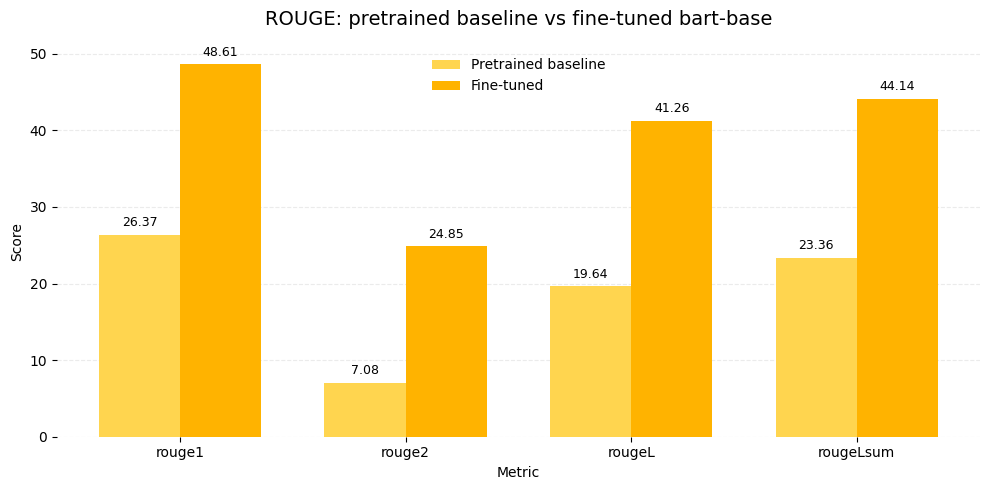

In [20]:
rouge_metrics = metrics_comparison_df[
    metrics_comparison_df["metric"].isin(
        ["rouge1", "rouge2", "rougeL", "rougeLsum"]
    )
].copy()

x = np.arange(len(rouge_metrics))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 5))

baseline_bars = ax.bar(
    x - width / 2,
    rouge_metrics["baseline"],
    width,
    label="Pretrained baseline",
    color="#FFD54F",
)

fine_tuned_bars = ax.bar(
    x + width / 2,
    rouge_metrics["fine_tuned"],
    width,
    label="Fine-tuned",
    color="#FFB300",
)

ax.set_title(
    "ROUGE: pretrained baseline vs fine-tuned bart-base",
    fontsize=14,
    pad=15,
)

ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(rouge_metrics["metric"])
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)
ax.legend(frameon=False)

for spine in ax.spines.values():
    spine.set_visible(False)

for bars in [baseline_bars, fine_tuned_bars]:
    for bar in bars:
        ax.annotate(
            f"{bar.get_height():.2f}",
            xy=(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
            ),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.tight_layout()
plt.show()


## Validation predictions


In [21]:
prediction_output = trainer.predict(
    tokenized_dataset["validation"],
    metric_key_prefix="validation",
)

prediction_ids = prediction_output.predictions

if isinstance(prediction_ids, tuple):
    prediction_ids = prediction_ids[0]

prediction_ids = np.asarray(prediction_ids)

if prediction_ids.ndim == 3:
    prediction_ids = np.argmax(
        prediction_ids,
        axis=-1,
    )

prediction_ids = np.where(
    prediction_ids < 0,
    tokenizer.pad_token_id,
    prediction_ids,
).astype(np.int64)

generated_summaries = tokenizer.batch_decode(
    prediction_ids,
    skip_special_tokens=True,
)

validation_results_df = pd.DataFrame({
    "dialogue": experiment_dataset["validation"][DIALOGUE_COL],
    "reference_summary": experiment_dataset["validation"][SUMMARY_COL],
    "generated_summary": generated_summaries,
})

validation_results_df["generated_words"] = (
    validation_results_df["generated_summary"]
    .str.split()
    .str.len()
)

validation_results_df["reference_words"] = (
    validation_results_df["reference_summary"]
    .str.split()
    .str.len()
)

validation_results_df.head()


,dialogue,reference_summary,generated_summary,generated_words,reference_words
0,"#Person1#: Hello, how are you doing today?\n#P...",#Person2# has trouble breathing. The doctor as...,#Person2#'s been having trouble breathing late...,19,18
1,#Person1#: Hey Jimmy. Let's go workout later t...,#Person1# invites Jimmy to go workout and pers...,#Person1# invites Jimmy to go to the gym. Jimm...,16,16
2,#Person1#: I need to stop eating such unhealth...,#Person1# plans to stop eating unhealthy foods...,#Person1# asks #Person2# to stop eating such u...,17,15
3,#Person1#: Do you believe in UFOs?\n#Person2#:...,#Person2# believes in UFOs and can see them in...,#Person2# tells #Person1# that UFOs are out th...,22,25
4,#Person1#: Did you go to school today?\n#Perso...,#Person1# didn't go to school today. #Person2#...,#Person1# didn't go to school today. #Person2#...,15,17


In [22]:
for row_index in range(min(5, len(validation_results_df))):
    row = validation_results_df.iloc[row_index]

    print("=" * 90)
    print("DIALOGUE:\n", row["dialogue"])
    print("\nREFERENCE:\n", row["reference_summary"])
    print("\nGENERATED:\n", row["generated_summary"])


DIALOGUE:
 #Person1#: Hello, how are you doing today?
#Person2#: I ' Ve been having trouble breathing lately.
#Person1#: Have you had any type of cold lately?
#Person2#: No, I haven ' t had a cold. I just have a heavy feeling in my chest when I try to breathe.
#Person1#: Do you have any allergies that you know of?
#Person2#: No, I don ' t have any allergies that I know of.
#Person1#: Does this happen all the time or mostly when you are active?
#Person2#: It happens a lot when I work out.
#Person1#: I am going to send you to a pulmonary specialist who can run tests on you for asthma.
#Person2#: Thank you for your help, doctor.

REFERENCE:
 #Person2# has trouble breathing. The doctor asks #Person2# about it and will send #Person2# to a pulmonary specialist.

GENERATED:
 #Person2#'s been having trouble breathing lately. #Person1# will send him to a pulmonary specialist to run tests for asthma.
DIALOGUE:
 #Person1#: Hey Jimmy. Let's go workout later today.
#Person2#: Sure. What time do you

## Validation BERTScore


In [23]:
bertscore_metric = evaluate.load("bertscore")

bertscore_results = bertscore_metric.compute(
    predictions=validation_results_df["generated_summary"].tolist(),
    references=validation_results_df["reference_summary"].tolist(),
    model_type="distilbert-base-uncased",
    batch_size=16,
    device="cuda" if torch.cuda.is_available() else "cpu",
)

validation_results_df["bertscore_precision"] = bertscore_results["precision"]
validation_results_df["bertscore_recall"] = bertscore_results["recall"]
validation_results_df["bertscore_f1"] = bertscore_results["f1"]

bertscore_summary = {
    "bertscore_precision": float(
        np.mean(bertscore_results["precision"])
    ),
    "bertscore_recall": float(
        np.mean(bertscore_results["recall"])
    ),
    "bertscore_f1": float(
        np.mean(bertscore_results["f1"])
    ),
}

bertscore_summary


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


{'bertscore_precision': 0.8732618055200679,
 'bertscore_recall': 0.8806822527144144,
 'bertscore_f1': 0.8766349195412957}

## Test evaluation


In [24]:
test_metrics = trainer.evaluate(
    eval_dataset=tokenized_dataset["test"],
    metric_key_prefix="test",
)

test_metrics


Training Loss,Validation Loss,Epoch,Rouge1,Rouge2,Rougel,Rougelsum,Gen Len
1.813297,1.395513,5,44.970300,18.860600,36.397000,39.598100,33.690000


{'test_loss': 1.3955134153366089,
 'test_rouge1': 44.9703,
 'test_rouge2': 18.8606,
 'test_rougeL': 36.397,
 'test_rougeLsum': 39.5981,
 'test_gen_len': 33.69}

## Test predictions і BERTScore


In [25]:
def clean_prediction_ids(predictions):
    if isinstance(predictions, tuple):
        predictions = predictions[0]

    predictions = np.asarray(predictions)

    if predictions.ndim == 3:
        predictions = np.argmax(
            predictions,
            axis=-1,
        )

    predictions = np.where(
        predictions < 0,
        tokenizer.pad_token_id,
        predictions,
    ).astype(np.int64)

    return predictions


test_prediction_output = trainer.predict(
    tokenized_dataset["test"],
    metric_key_prefix="test_prediction",
)

test_prediction_ids = clean_prediction_ids(
    test_prediction_output.predictions
)

test_generated_summaries = tokenizer.batch_decode(
    test_prediction_ids,
    skip_special_tokens=True,
)

test_results_df = pd.DataFrame({
    "test_index": np.arange(
        len(experiment_dataset["test"])
    ),
    "dialogue": experiment_dataset["test"][DIALOGUE_COL],
    "reference_summary": experiment_dataset["test"][SUMMARY_COL],
    "generated_summary": test_generated_summaries,
})

test_results_df["dialogue_words"] = (
    test_results_df["dialogue"]
    .str.split()
    .str.len()
)

test_results_df["reference_words"] = (
    test_results_df["reference_summary"]
    .str.split()
    .str.len()
)

test_results_df["generated_words"] = (
    test_results_df["generated_summary"]
    .str.split()
    .str.len()
)

test_results_df.head()


,test_index,dialogue,reference_summary,generated_summary,dialogue_words,reference_words,generated_words
0,0,"#Person1#: Ms. Dawson, I need you to take a di...",Ms. Dawson helps #Person1# to write a memo to ...,Ms. Dawson gives #Person1# a dictation of an i...,221,27,36
1,1,"#Person1#: Ms. Dawson, I need you to take a di...",In order to prevent employees from wasting tim...,Ms. Dawson gives #Person1# a dictation of an i...,221,36,36
2,2,"#Person1#: Ms. Dawson, I need you to take a di...",Ms. Dawson takes a dictation for #Person1# abo...,Ms. Dawson gives #Person1# a dictation of an i...,221,27,36
3,3,#Person1#: You're finally here! What took so l...,#Person2# arrives late because of traffic jam....,#Person2# got stuck in traffic again. #Person1...,209,22,24
4,4,#Person1#: You're finally here! What took so l...,#Person2# decides to follow #Person1#'s sugges...,#Person2# got stuck in traffic again. #Person1...,209,18,24


In [26]:
test_bertscore_results = bertscore_metric.compute(
    predictions=test_results_df["generated_summary"].tolist(),
    references=test_results_df["reference_summary"].tolist(),
    model_type="distilbert-base-uncased",
    batch_size=16,
    device="cuda" if torch.cuda.is_available() else "cpu",
)

test_results_df["bertscore_precision"] = (
    test_bertscore_results["precision"]
)
test_results_df["bertscore_recall"] = (
    test_bertscore_results["recall"]
)
test_results_df["bertscore_f1"] = (
    test_bertscore_results["f1"]
)

test_bertscore_summary = {
    "bertscore_precision": float(
        np.mean(test_bertscore_results["precision"])
    ),
    "bertscore_recall": float(
        np.mean(test_bertscore_results["recall"])
    ),
    "bertscore_f1": float(
        np.mean(test_bertscore_results["f1"])
    ),
}

test_bertscore_summary


{'bertscore_precision': 0.8588168432859249,
 'bertscore_recall': 0.8743804434088939,
 'bertscore_f1': 0.8661849505599888}

## Ручне оцінювання (генерація шаблону файлу)


In [27]:
MANUAL_SAMPLE_SIZE = min(
    50,
    len(test_results_df),
)

manual_evaluation_df = (
    test_results_df
    .sample(
        n=MANUAL_SAMPLE_SIZE,
        random_state=SEED,
    )
    .sort_values("test_index")
    .reset_index(drop=True)
    .copy()
)

manual_evaluation_df.insert(
    0,
    "sample_id",
    np.arange(1, len(manual_evaluation_df) + 1),
)

HUMAN_SCORE_COLUMNS = [
    "human_factual_consistency",
    "human_coverage_relevance",
    "human_speaker_attribution",
    "human_fluency_coherence",
    "human_conciseness",
]

for column_name in HUMAN_SCORE_COLUMNS:
    manual_evaluation_df[column_name] = np.nan

manual_evaluation_df["human_comments"] = ""

manual_evaluation_path = (
    RESULTS_DIR
    / f"{EXPERIMENT_NAME}_manual_evaluation_50.csv"
)

manual_evaluation_df.to_csv(
    manual_evaluation_path,
    index=False,
)

print("Шаблон збережено:", manual_evaluation_path)
print("Заповни п'ять колонок оцінками від 1 до 5.")
display(manual_evaluation_df)


Шаблон збережено: /content/chatbrief/results/bart_base_full_with_test_manual_evaluation_50.csv
Заповни п'ять колонок оцінками від 1 до 5.


,sample_id,test_index,dialogue,reference_summary,generated_summary,dialogue_words,reference_words,generated_words,bertscore_precision,bertscore_recall,bertscore_f1,human_factual_consistency,human_coverage_relevance,human_speaker_attribution,human_fluency_coherence,human_conciseness,human_comments
0,1,49,#Person1#: Yeah. Just pull on this strip. Then...,#Person1# plans on playing a trick to others. ...,#Person1# tells #Person2# to pull on the strip...,81,17,24,0.786734,0.810686,0.798530,NaN,NaN,NaN,NaN,NaN,
1,2,51,"#Person1#: What does your sister look like, Mi...",Mike is describing his sister to #Person1#.,Mike tells #Person1# what his sister looks like.,46,7,8,0.862484,0.867623,0.865046,NaN,NaN,NaN,NaN,NaN,
2,3,67,"#Person1#: Excuse me.\n#Person2#: Yes, sir. Ca...",#Person2# will change a steak for #Person1# as...,#Person2# helps #Person1# order a medium-rare ...,84,13,7,0.892552,0.866215,0.879186,NaN,NaN,NaN,NaN,NaN,
3,4,76,#Person1#: Do you drink much?\n#Person2#: Depe...,"#Person2#, a heavy drinker, invites #Person1#,...",#Person1# and #Person2# talk about their drink...,204,25,38,0.805244,0.828728,0.816818,NaN,NaN,NaN,NaN,NaN,
4,5,115,"#Person1#: Maggie, can I borrow your notes for...",Mark asks Maggie for her history notes because...,Maggie borrows Mark's notes for history from t...,201,22,30,0.769310,0.832118,0.799483,NaN,NaN,NaN,NaN,NaN,
5,6,123,#Person1#: What do you think of this one? \n#P...,#Person1# is showing the new clothes to #Perso...,#Person1# thinks #Person2#'s new clothes are t...,186,20,29,0.873942,0.901796,0.887650,NaN,NaN,NaN,NaN,NaN,
6,7,203,#Person1#: Good evening. Welcome to our restau...,James has reserved a dining room and #Person1#...,#Person1# helps James reserve a table in the d...,84,16,10,0.834866,0.803944,0.819114,NaN,NaN,NaN,NaN,NaN,
7,8,218,#Person1#: What are you working on?\n#Person2#...,#Person2# introduces the shopping budget which...,#Person2# is making a shopping budget to save ...,88,17,15,0.926136,0.917974,0.922037,NaN,NaN,NaN,NaN,NaN,
8,9,220,"#Person1#: Where are you going, Jane?\n#Person...",Jane will go to the hospital to visit Susan. H...,Jane tells Henry she's going to the hospital t...,108,18,22,0.884568,0.904157,0.894255,NaN,NaN,NaN,NaN,NaN,
9,10,270,#Person1#: It depends on where you are and wha...,#Person1# hates those who keep smiling at #Per...,#Person1# and #Person2# are fed up with those ...,103,24,15,0.924209,0.904126,0.914057,NaN,NaN,NaN,NaN,NaN,


In [28]:
from google.colab import files

files.download(str(manual_evaluation_path))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## OpenRouter LLM-as-a-Judge

In [30]:
OPENROUTER_SAMPLE_SIZE = 50
OPENROUTER_MODEL_NAME = "openai/gpt-4.1-mini"
OPENROUTER_API_URL = "https://openrouter.ai/api/v1/chat/completions"

JUDGE_PASS_THRESHOLD = 4
MAX_RETRIES = 4
REQUEST_DELAY_SECONDS = 0.3
OVERWRITE_EXISTING_RESULTS = True

safe_model_name = (
    OPENROUTER_MODEL_NAME
    .replace("/", "_")
    .replace(":", "_")
)

openrouter_results_path = (
    RESULTS_DIR
    / f"{EXPERIMENT_NAME}_openrouter_judge_{safe_model_name}.csv"
)

openrouter_summary_path = (
    RESULTS_DIR
    / f"{EXPERIMENT_NAME}_openrouter_judge_{safe_model_name}_summary.csv"
)

print("Judge model:", OPENROUTER_MODEL_NAME)
print("Results:", openrouter_results_path)


Judge model: openai/gpt-4.1-mini
Results: /content/chatbrief/results/bart_base_full_with_test_openrouter_judge_openai_gpt-4.1-mini.csv


In [31]:
OPENROUTER_API_KEY = (
    os.getenv("OPENROUTER_API_KEY")
    or getpass("Введи OpenRouter API key: ")
)

if not OPENROUTER_API_KEY.strip():
    raise ValueError("OpenRouter API key не введено.")


Введи OpenRouter API key: ··········


In [32]:
judge_sample_df = (
    manual_evaluation_df
    .head(OPENROUTER_SAMPLE_SIZE)
    .copy()
    .reset_index(drop=True)
)

required_columns = [
    "sample_id",
    "test_index",
    "dialogue",
    "reference_summary",
    "generated_summary",
]

missing_columns = [
    column
    for column in required_columns
    if column not in judge_sample_df.columns
]

if missing_columns:
    raise ValueError(f"У таблиці немає колонок: {missing_columns}")

print("Кількість прикладів:", len(judge_sample_df))
display(judge_sample_df[required_columns].head())


Кількість прикладів: 50


,sample_id,test_index,dialogue,reference_summary,generated_summary
0,1,49,#Person1#: Yeah. Just pull on this strip. Then...,#Person1# plans on playing a trick to others. ...,#Person1# tells #Person2# to pull on the strip...
1,2,51,"#Person1#: What does your sister look like, Mi...",Mike is describing his sister to #Person1#.,Mike tells #Person1# what his sister looks like.
2,3,67,"#Person1#: Excuse me.\n#Person2#: Yes, sir. Ca...",#Person2# will change a steak for #Person1# as...,#Person2# helps #Person1# order a medium-rare ...
3,4,76,#Person1#: Do you drink much?\n#Person2#: Depe...,"#Person2#, a heavy drinker, invites #Person1#,...",#Person1# and #Person2# talk about their drink...
4,5,115,"#Person1#: Maggie, can I borrow your notes for...",Mark asks Maggie for her history notes because...,Maggie borrows Mark's notes for history from t...


In [33]:
JUDGE_CRITERIA = [
    "factual_consistency",
    "coverage_relevance",
    "speaker_attribution",
    "fluency_coherence",
    "conciseness",
]

criterion_schema = {
    "type": "object",
    "properties": {
        "score": {
            "type": "integer",
            "minimum": 1,
            "maximum": 5,
        },
        "reason": {
            "type": "string",
        },
    },
    "required": ["score", "reason"],
    "additionalProperties": False,
}

JUDGE_RESPONSE_SCHEMA = {
    "type": "object",
    "properties": {
        **{
            criterion: criterion_schema
            for criterion in JUDGE_CRITERIA
        },
        "overall_comment": {
            "type": "string",
        },
    },
    "required": [
        *JUDGE_CRITERIA,
        "overall_comment",
    ],
    "additionalProperties": False,
}


def validate_judge_response(evaluation):
    if not isinstance(evaluation, dict):
        raise ValueError("Judge response має бути JSON object.")

    for criterion in JUDGE_CRITERIA:
        result = evaluation.get(criterion)

        if not isinstance(result, dict):
            raise ValueError(f"Немає результату для {criterion}.")

        score = result.get("score")
        reason = result.get("reason")

        if (
            not isinstance(score, int)
            or isinstance(score, bool)
            or not 1 <= score <= 5
        ):
            raise ValueError(
                f"Некоректний score для {criterion}: {score}"
            )

        if not isinstance(reason, str) or not reason.strip():
            raise ValueError(f"Немає reason для {criterion}.")

    if not isinstance(evaluation.get("overall_comment"), str):
        raise ValueError("Немає overall_comment.")


In [34]:
SYSTEM_PROMPT = """
You are an expert evaluator of dialogue summarization systems.

Your task is to evaluate a GENERATED SUMMARY of an ORIGINAL DIALOGUE.

The ORIGINAL DIALOGUE is the primary source of truth.
The REFERENCE SUMMARY is only an additional guide to the important
content. A generated summary may use different wording and still be
fully correct.

Evaluate the generated summary independently according to exactly
five criteria.

Use only integer scores from 1 to 5.

GENERAL SCORING SCALE

1 = Very poor
The summary has a serious failure for this criterion and is
unreliable or unusable.

2 = Poor
The summary has one or more major problems that significantly
reduce its quality.

3 = Acceptable
The main idea is understandable, but there are noticeable
problems, errors or omissions.

4 = Good
The summary satisfies the criterion. There may be one minor issue,
but it does not change the central meaning.

5 = Excellent
The summary fully satisfies the criterion and has no meaningful
problems.

CRITERION 1: FACTUAL CONSISTENCY

Check whether every claim in the generated summary is supported
by the original dialogue.

Penalize:
- invented or unsupported facts;
- contradictions with the dialogue;
- incorrect actions, decisions, dates, numbers or relationships;
- incorrect descriptions of intentions or emotions;
- claims that exaggerate or change the original meaning.

Do not penalize valid paraphrasing.

Score 5 only when every factual claim is supported by the dialogue.
Score 4 when there is at most one very minor imprecision that does
not change the main meaning.

CRITERION 2: COVERAGE AND RELEVANCE

Check whether the generated summary captures:
- the central topic;
- important actions;
- important decisions;
- intentions and reasons;
- the final result or outcome, when present.

Penalize:
- omission of important events, decisions or outcomes;
- focusing on secondary details instead of the main point;
- inclusion of irrelevant information;
- a summary that is too vague to represent the conversation.

Do not require the generated summary to copy the wording of the
reference summary.

Score 5 when all essential information is included without
irrelevant details.
Score 4 when the central content is covered with at most one
minor omission.

CRITERION 3: SPEAKER ATTRIBUTION

Check whether actions, statements, opinions, intentions, decisions
and emotions are attributed to the correct speakers.

Penalize:
- assigning one speaker's statement or action to another;
- changing who proposed, wanted or decided something;
- incorrectly merging the intentions of different speakers;
- saying that both speakers agreed when the dialogue does not
  support that conclusion.

Do not penalize neutral plural wording when the dialogue clearly
supports a joint action or decision.

When the generated summary contains no explicit speaker
attribution, do not invent an attribution error.

Score 5 when every attribution is correct.
Score 4 when there is at most a minor ambiguity that does not
change the meaning.

CRITERION 4: FLUENCY AND COHERENCE

Evaluate:
- grammar;
- sentence completeness;
- natural wording;
- readability;
- logical connection between ideas;
- whether the summary is understandable as a standalone text.

Penalize:
- sentence fragments;
- confusing or unnatural wording;
- grammar errors;
- contradictions inside the summary;
- awkward repetition.

Score 5 when the summary is natural, grammatical and coherent.
Score 4 when it is clear and readable with at most one minor
language issue.

CRITERION 5: CONCISENESS

Check whether the summary is concise while preserving the
essential meaning of the dialogue.

Penalize:
- repetition;
- greetings and conversational filler;
- unnecessary examples or secondary details;
- excessive verbosity;
- extreme brevity that removes the central topic, decision
  or outcome.

Score 5 when the summary is compact, focused and complete.
Score 4 when its length is appropriate with at most a small amount
of unnecessary detail.

IMPORTANT RULES

- Evaluate each criterion separately.
- Return integer scores only: 1, 2, 3, 4 or 5.
- Do not use decimal scores.
- Do not use a 0–1 scale.
- Do not use a 0–10 scale.
- Do not calculate an overall numeric score.
- Do not reward the generated summary merely for copying words
  from the reference.
- Do not penalize accurate paraphrasing.
- Reasons must be short and based on concrete evidence from the
  dialogue and generated summary.
""".strip()

In [35]:
def evaluate_summary_with_openrouter(
    dialogue,
    reference_summary,
    generated_summary,
):
    user_prompt = f"""
ORIGINAL DIALOGUE:
<dialogue>
{dialogue}
</dialogue>

REFERENCE SUMMARY:
<reference_summary>
{reference_summary}
</reference_summary>

GENERATED SUMMARY:
<generated_summary>
{generated_summary}
</generated_summary>

Evaluate the GENERATED SUMMARY according to all five criteria.
Return the result using the required JSON schema.
""".strip()

    request_body = {
        "model": OPENROUTER_MODEL_NAME,
        "messages": [
            {
                "role": "system",
                "content": SYSTEM_PROMPT,
            },
            {
                "role": "user",
                "content": user_prompt,
            },
        ],
        "temperature": 0,
        "max_completion_tokens": 1200,
        "response_format": {
            "type": "json_schema",
            "json_schema": {
                "name": "summary_evaluation",
                "strict": True,
                "schema": JUDGE_RESPONSE_SCHEMA,
            },
        },
        "provider": {
            "require_parameters": True,
        },
    }

    headers = {
        "Authorization": (
            f"Bearer {OPENROUTER_API_KEY}"
        ),
        "Content-Type": "application/json",
    }

    last_error = None

    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = requests.post(
                OPENROUTER_API_URL,
                headers=headers,
                json=request_body,
                timeout=120,
            )

            if response.status_code == 429:
                wait_seconds = 2 ** attempt

                print(
                    "Rate limit. Повтор через",
                    wait_seconds,
                    "секунд..."
                )

                time.sleep(wait_seconds)
                continue

            if response.status_code >= 500:
                wait_seconds = 2 ** attempt

                print(
                    "Тимчасова помилка сервера",
                    response.status_code,
                    "- повтор через",
                    wait_seconds,
                    "секунд..."
                )

                time.sleep(wait_seconds)
                continue

            if not response.ok:
                raise RuntimeError(
                    "OpenRouter API error "
                    f"{response.status_code}: "
                    f"{response.text}"
                )

            response_json = response.json()

            if not response_json.get("choices"):
                raise RuntimeError(
                    "OpenRouter не повернув choices: "
                    f"{response_json}"
                )

            message = (
                response_json["choices"][0]["message"]
            )

            content = message.get("content")

            if not content:
                raise RuntimeError(
                    "Judge повернув порожню відповідь."
                )

            if isinstance(content, dict):
                evaluation = content
            else:
                evaluation = json.loads(content)

            validate_judge_response(
                evaluation
            )

            usage = response_json.get(
                "usage",
                {},
            )

            metadata = {
                "openrouter_response_id": (
                    response_json.get("id")
                ),
                "returned_model": (
                    response_json.get("model")
                ),
                "prompt_tokens": usage.get(
                    "prompt_tokens"
                ),
                "completion_tokens": usage.get(
                    "completion_tokens"
                ),
                "total_tokens": usage.get(
                    "total_tokens"
                ),
            }

            return evaluation, metadata

        except (
            requests.RequestException,
            json.JSONDecodeError,
            RuntimeError,
            ValueError,
        ) as error:
            last_error = error

            if attempt < MAX_RETRIES:
                wait_seconds = 2 ** attempt

                print(
                    f"Спроба {attempt} невдала:",
                    str(error)[:300],
                )

                print(
                    "Повтор через",
                    wait_seconds,
                    "секунд..."
                )

                time.sleep(wait_seconds)

    raise RuntimeError(
        "Не вдалося отримати коректну оцінку "
        f"після {MAX_RETRIES} спроб. "
        f"Остання помилка: {last_error}"
    )

In [36]:
if (
    OVERWRITE_EXISTING_RESULTS
    and openrouter_results_path.exists()
):
    openrouter_results_path.unlink()

    print(
        "Старий файл видалено:",
        openrouter_results_path,
    )


judge_rows = []

for row_number, row in (
    judge_sample_df.iterrows()
):
    print(
        f"Evaluating "
        f"{row_number + 1}/"
        f"{len(judge_sample_df)}..."
    )

    result_row = {
        "sample_id": int(row["sample_id"]),
        "test_index": int(row["test_index"]),
        "judge_model": (
            OPENROUTER_MODEL_NAME
        ),
        "dialogue": row["dialogue"],
        "reference_summary": (
            row["reference_summary"]
        ),
        "generated_summary": (
            row["generated_summary"]
        ),
    }

    try:
        evaluation, metadata = (
            evaluate_summary_with_openrouter(
                dialogue=row["dialogue"],
                reference_summary=(
                    row["reference_summary"]
                ),
                generated_summary=(
                    row["generated_summary"]
                ),
            )
        )

        criterion_scores = []

        for criterion in JUDGE_CRITERIA:
            score = int(
                evaluation[criterion]["score"]
            )

            reason = (
                evaluation[criterion]["reason"]
            )

            result_row[
                f"judge_{criterion}_score"
            ] = score

            result_row[
                f"judge_{criterion}_passed"
            ] = (
                score
                >= JUDGE_PASS_THRESHOLD
            )

            result_row[
                f"judge_{criterion}_reason"
            ] = reason

            criterion_scores.append(score)

        result_row[
            "judge_mean_score_1_to_5"
        ] = float(
            np.mean(criterion_scores)
        )

        result_row[
            "judge_overall_passed"
        ] = all(
            score >= JUDGE_PASS_THRESHOLD
            for score in criterion_scores
        )

        result_row[
            "judge_overall_comment"
        ] = evaluation["overall_comment"]

        result_row.update(metadata)

        result_row["evaluation_error"] = ""

    except Exception as error:
        print(
            "Помилка на sample_id",
            row["sample_id"],
            ":",
            error,
        )

        for criterion in JUDGE_CRITERIA:
            result_row[
                f"judge_{criterion}_score"
            ] = np.nan

            result_row[
                f"judge_{criterion}_passed"
            ] = False

            result_row[
                f"judge_{criterion}_reason"
            ] = ""

        result_row[
            "judge_mean_score_1_to_5"
        ] = np.nan

        result_row[
            "judge_overall_passed"
        ] = False

        result_row[
            "judge_overall_comment"
        ] = ""

        result_row[
            "evaluation_error"
        ] = (
            f"{type(error).__name__}: {error}"
        )

    judge_rows.append(result_row)

    openrouter_results_df = pd.DataFrame(
        judge_rows
    )

    openrouter_results_df.to_csv(
        openrouter_results_path,
        index=False,
    )

    time.sleep(REQUEST_DELAY_SECONDS)


print(
    "Оцінювання завершено:",
    openrouter_results_path,
)

display(openrouter_results_df.head())


Evaluating 1/50...
Evaluating 2/50...
Evaluating 3/50...
Evaluating 4/50...
Evaluating 5/50...
Evaluating 6/50...
Evaluating 7/50...
Evaluating 8/50...
Evaluating 9/50...
Evaluating 10/50...
Evaluating 11/50...
Evaluating 12/50...
Evaluating 13/50...
Evaluating 14/50...
Evaluating 15/50...
Evaluating 16/50...
Evaluating 17/50...
Evaluating 18/50...
Evaluating 19/50...
Evaluating 20/50...
Evaluating 21/50...
Evaluating 22/50...
Evaluating 23/50...
Evaluating 24/50...
Evaluating 25/50...
Evaluating 26/50...
Evaluating 27/50...
Evaluating 28/50...
Evaluating 29/50...
Evaluating 30/50...
Evaluating 31/50...
Evaluating 32/50...
Evaluating 33/50...
Evaluating 34/50...
Evaluating 35/50...
Evaluating 36/50...
Evaluating 37/50...
Evaluating 38/50...
Evaluating 39/50...
Evaluating 40/50...
Evaluating 41/50...
Evaluating 42/50...
Evaluating 43/50...
Evaluating 44/50...
Evaluating 45/50...
Evaluating 46/50...
Evaluating 47/50...
Evaluating 48/50...
Evaluating 49/50...
Evaluating 50/50...
Оцінюванн

,sample_id,test_index,judge_model,dialogue,reference_summary,generated_summary,judge_factual_consistency_score,judge_factual_consistency_passed,judge_factual_consistency_reason,judge_coverage_relevance_score,...,judge_conciseness_reason,judge_mean_score_1_to_5,judge_overall_passed,judge_overall_comment,openrouter_response_id,returned_model,prompt_tokens,completion_tokens,total_tokens,evaluation_error
0,1,49,openai/gpt-4.1-mini,#Person1#: Yeah. Just pull on this strip. Then...,#Person1# plans on playing a trick to others. ...,#Person1# tells #Person2# to pull on the strip...,2,False,The summary incorrectly states that the old la...,2,...,"The summary is concise and focused, though it ...",3.4,False,The summary is concise and mostly clear but co...,gen-1786310657-6LWSiABpGwnl3NaV6BfZ,openai/gpt-4.1-mini,1324,245,1569,
1,2,51,openai/gpt-4.1-mini,"#Person1#: What does your sister look like, Mi...",Mike is describing his sister to #Person1#.,Mike tells #Person1# what his sister looks like.,5,True,The summary accurately states that Mike tells ...,3,...,The summary is concise and focused without unn...,4.6,False,"The summary is factually accurate, concise, an...",gen-1786310660-EhxnZEXx3MvWcsNg19au,openai/gpt-4.1-mini,1252,173,1425,
2,3,67,openai/gpt-4.1-mini,"#Person1#: Excuse me.\n#Person2#: Yes, sir. Ca...",#Person2# will change a steak for #Person1# as...,#Person2# helps #Person1# order a medium-rare ...,2,False,The summary incorrectly states that Person2 he...,2,...,"The summary is concise and focused, though it ...",3.8,False,The summary is fluent and concise but factuall...,gen-1786310664-DIqvp2QT1cpwtICdfVMj,openai/gpt-4.1-mini,1316,223,1539,
3,4,76,openai/gpt-4.1-mini,#Person1#: Do you drink much?\n#Person2#: Depe...,"#Person2#, a heavy drinker, invites #Person1#,...",#Person1# and #Person2# talk about their drink...,3,False,The summary incorrectly states that both #Pers...,4,...,The summary is concise and focused without unn...,4.2,False,The summary captures the main topic and the pl...,gen-1786310667-T3RzGoALs733hyD4VznT,openai/gpt-4.1-mini,1541,245,1786,
4,5,115,openai/gpt-4.1-mini,"#Person1#: Maggie, can I borrow your notes for...",Mark asks Maggie for her history notes because...,Maggie borrows Mark's notes for history from t...,2,False,The summary incorrectly states that Maggie bor...,3,...,The summary is concise and focused without unn...,3.2,False,The generated summary is concise and mostly co...,gen-1786310671-egV4xCoRRmm6JBv9H0PU,openai/gpt-4.1-mini,1494,267,1761,


## Training history


In [37]:
history_df = pd.DataFrame(
    trainer.state.log_history
)

history_df


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_model_preparation_time,eval_rouge1,eval_rouge2,eval_rougeL,...,test_loss,test_model_preparation_time,test_rouge1,test_rouge2,test_rougeL,test_rougeLsum,test_gen_len,test_runtime,test_samples_per_second,test_steps_per_second
0,7.568214,41.756618,9.242619e-07,0.016051,25,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6.204948,23.820808,1.887035e-06,0.032103,50,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.860697,18.022688,2.849807e-06,0.048154,75,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.000364,13.915202,3.812580e-06,0.064205,100,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3.753364,14.655437,4.775353e-06,0.080257,125,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,1.813297,9.633933,6.846384e-08,4.990690,7775,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
315,NaN,NaN,NaN,5.000000,7790,1.124357,0.0046,48.4418,24.1187,40.7564,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
316,NaN,NaN,NaN,5.000000,7790,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
317,NaN,NaN,NaN,5.000000,7790,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


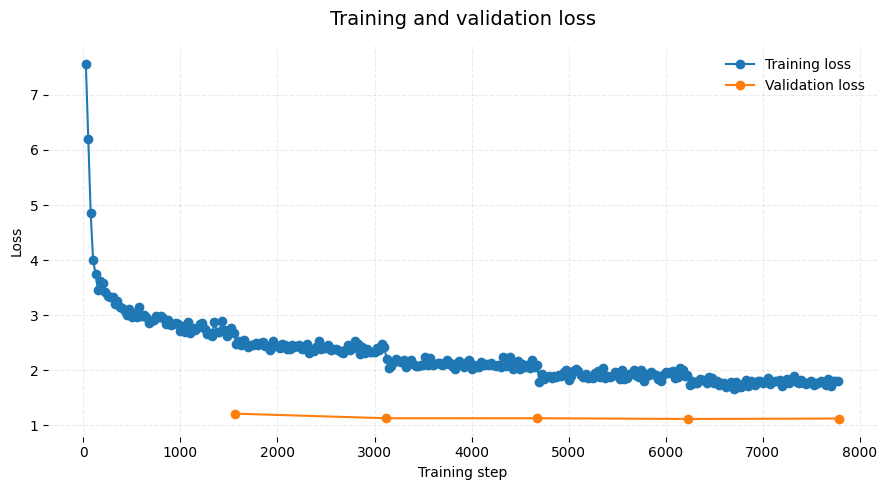

In [38]:
train_history = history_df.dropna(
    subset=["loss"],
    how="any",
)

eval_history = history_df.dropna(
    subset=["eval_loss"],
    how="any",
)

fig, ax = plt.subplots(figsize=(9, 5))

if not train_history.empty:
    ax.plot(
        train_history["step"],
        train_history["loss"],
        marker="o",
        label="Training loss",
    )

if not eval_history.empty:
    ax.plot(
        eval_history["step"],
        eval_history["eval_loss"],
        marker="o",
        label="Validation loss",
    )

ax.set_title(
    "Training and validation loss",
    fontsize=14,
    pad=15,
)

ax.set_xlabel("Training step")
ax.set_ylabel("Loss")
ax.grid(linestyle="--", alpha=0.25)
ax.set_axisbelow(True)
ax.legend(frameon=False)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()


## Збереження результатів


In [39]:
trainer.save_model(str(FINAL_MODEL_DIR))
tokenizer.save_pretrained(str(FINAL_MODEL_DIR))

validation_results_path = (
    RESULTS_DIR
    / f"{EXPERIMENT_NAME}_validation_predictions.csv"
)
test_results_path = (
    RESULTS_DIR
    / f"{EXPERIMENT_NAME}_test_predictions.csv"
)
history_path = (
    RESULTS_DIR
    / f"{EXPERIMENT_NAME}_training_history.csv"
)
metrics_path = (
    RESULTS_DIR
    / f"{EXPERIMENT_NAME}_metrics.json"
)

validation_results_df.to_csv(validation_results_path, index=False)
test_results_df.to_csv(test_results_path, index=False)
history_df.to_csv(history_path, index=False)

all_metrics = {
    "configuration": {
        "model_name": MODEL_NAME,
        "experiment_name": EXPERIMENT_NAME,
        "train_size": len(experiment_dataset["train"]),
        "validation_size": len(experiment_dataset["validation"]),
        "test_size": len(experiment_dataset["test"]),
        "epochs": NUM_EPOCHS,
        "learning_rate": LEARNING_RATE,
        "train_batch_size": TRAIN_BATCH_SIZE,
        "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
        "max_input_length": MAX_INPUT_LENGTH,
        "max_target_length": MAX_TARGET_LENGTH,
        "seed": SEED,
    },
    "baseline_metrics": globals().get("baseline_metrics"),
    "validation_metrics": globals().get("final_metrics"),
    "validation_bertscore": globals().get("bertscore_summary"),
    "test_metrics": globals().get("test_metrics"),
    "test_bertscore": globals().get("test_bertscore_summary"),
    "best_checkpoint": trainer.state.best_model_checkpoint,
    "human_quality_pass_rate": globals().get(
        "human_quality_pass_rate"
    ),
    "openrouter_judge_model": globals().get(
        "OPENROUTER_MODEL_NAME"
    ),
    "openrouter_quality_pass_rate": globals().get(
        "openrouter_quality_pass_rate"
    ),
    "openrouter_average_score": globals().get(
        "openrouter_average_score"
    ),
}

with open(metrics_path, "w", encoding="utf-8") as file:
    json.dump(
        all_metrics,
        file,
        indent=2,
        ensure_ascii=False,
        default=str,
    )

print("Model:", FINAL_MODEL_DIR)
print("Validation predictions:", validation_results_path)
print("Test predictions:", test_results_path)
print("Manual evaluation template:", manual_evaluation_path)
print("Metrics:", metrics_path)
print("History:", history_path)

if "openrouter_results_path" in globals():
    print("OpenRouter results:", openrouter_results_path)

if "openrouter_summary_path" in globals():
    print("OpenRouter summary:", openrouter_summary_path)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model: /content/chatbrief/models/bart_base_full_with_test_best
Validation predictions: /content/chatbrief/results/bart_base_full_with_test_validation_predictions.csv
Test predictions: /content/chatbrief/results/bart_base_full_with_test_test_predictions.csv
Manual evaluation template: /content/chatbrief/results/bart_base_full_with_test_manual_evaluation_50.csv
Metrics: /content/chatbrief/results/bart_base_full_with_test_metrics.json
History: /content/chatbrief/results/bart_base_full_with_test_training_history.csv
OpenRouter results: /content/chatbrief/results/bart_base_full_with_test_openrouter_judge_openai_gpt-4.1-mini.csv
OpenRouter summary: /content/chatbrief/results/bart_base_full_with_test_openrouter_judge_openai_gpt-4.1-mini_summary.csv


## Завантаження архіву


In [40]:
archive_base = f"/content/{EXPERIMENT_NAME}_experiment"

archive_path = shutil.make_archive(
    archive_base,
    "zip",
    root_dir=PROJECT_DIR,
)

print("Archive:", archive_path)


Archive: /content/bart_base_full_with_test_experiment.zip


In [41]:
from google.colab import files

files.download(archive_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>